# E-Commerce Customer Segmentation

Python libraries like Numpy and pandas, and ML techniques like K-Means Clustering have been used in this project to analyze consumer data and study demographic and spending-related attributes such as age, annual income, and spending score. I have also made use of other methods like data processing, EDA, feature scaling, clustering, and visualization of customer segments.

### Importing the necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

### Importing the Dataset

In [3]:
df = pd.read_csv("../datasets/store_customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [4]:
df.shape

(1000, 5)

In [5]:
df.info

<bound method DataFrame.info of      CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)
0          1000      M  39.0                59.9                    58.0
1          1001      M  34.0                48.4                    37.0
2          1002      F  40.0                70.5                    26.0
3          1003      F  47.0                81.1                    30.0
4          1004      F  33.0                42.1                    58.0
..          ...    ...   ...                 ...                     ...
995        1995      M  80.0               133.3                     1.0
996        1996      M  44.0                82.6                    40.0
997        1997      F  46.0                67.7                    26.0
998        1998      F  28.0                45.7                    59.0
999        1999      M  67.0               107.8                     1.0

[1000 rows x 5 columns]>

In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [7]:
df.dtypes

CustomerID                  int64
Gender                     object
Age                       float64
Annual Income (k$)        float64
Spending Score (1-100)    float64
dtype: object

In [8]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

### Cleaning the Data

In [9]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [32]:
df = df.dropna()

In [33]:
print(df.shape)

(982, 5)


In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df = df.drop_duplicates()

In [36]:
df.rename(columns={
    "Annual Income (k$)": "Annual_Income",
    "Spending Score (1-100)": "Spending_Score"
}, inplace=True)

In [37]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score'], dtype='object')

In [38]:
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())

(982, 5)
CustomerID        0
Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64
0


In [39]:
df.to_csv("../datasets/Mall_Customers_Clean.csv", index=False)

### Time for the EDA

In [37]:
df["Gender"].value_counts()

Gender
F    522
M    475
Name: count, dtype: int64

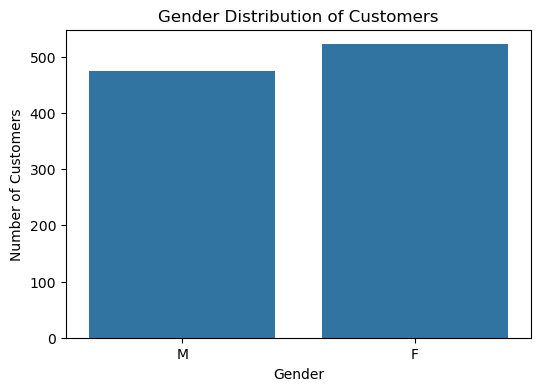

In [38]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender")
plt.title("Gender Distribution of Customers")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

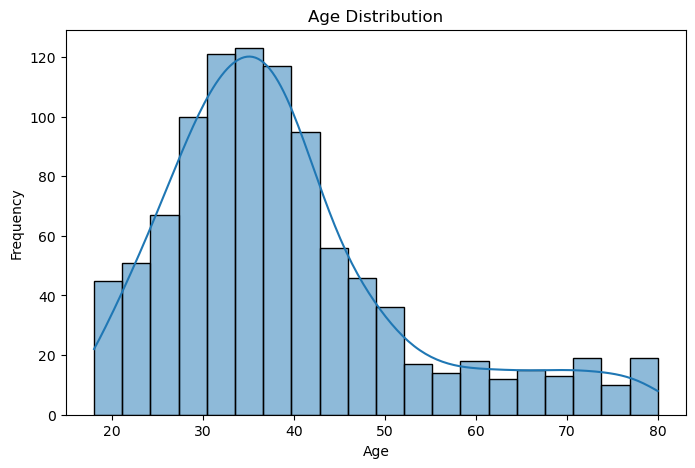

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

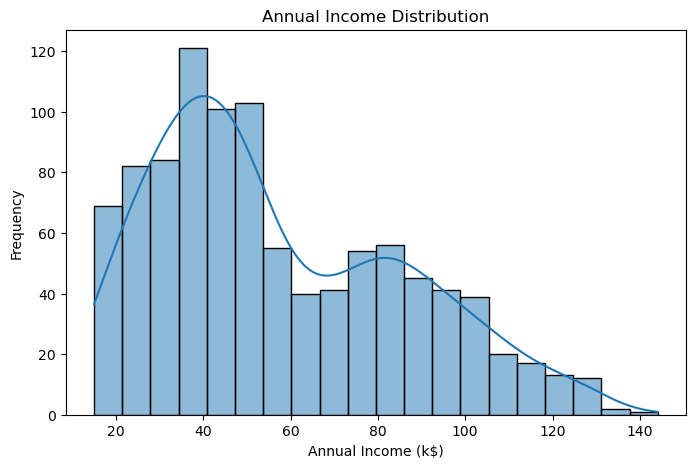

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(df["Annual_Income"], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Frequency")
plt.show()

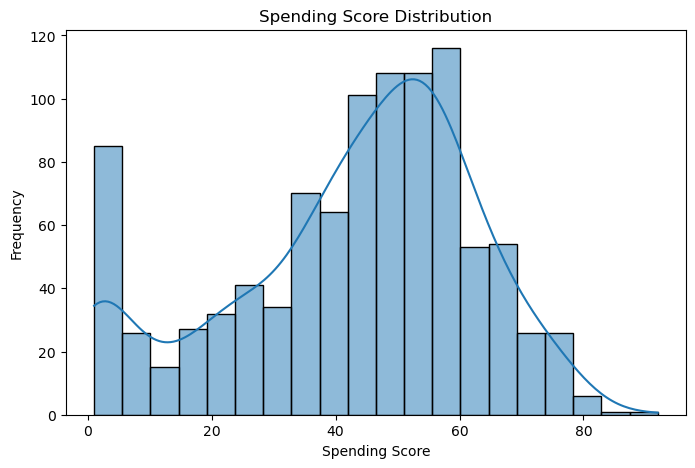

In [41]:
plt.figure(figsize=(8,5))
sns.histplot(df["Spending_Score"], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Frequency")
plt.show()

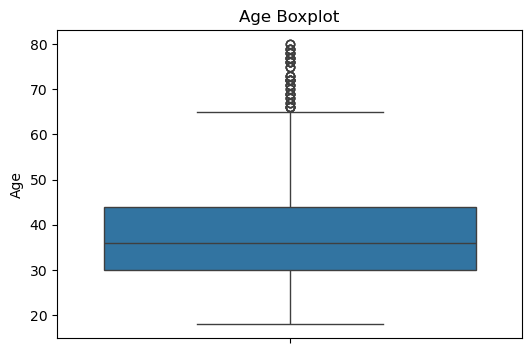

In [42]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Age"])
plt.title("Age Boxplot")
plt.show()

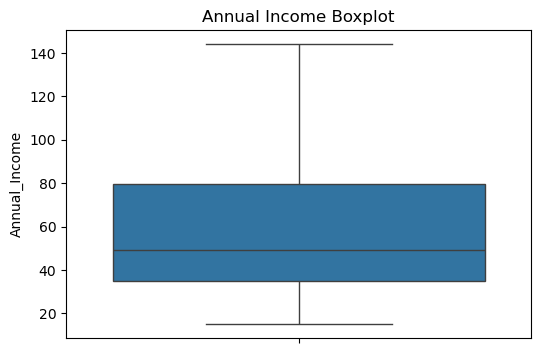

In [43]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Annual_Income"])
plt.title("Annual Income Boxplot")
plt.show()

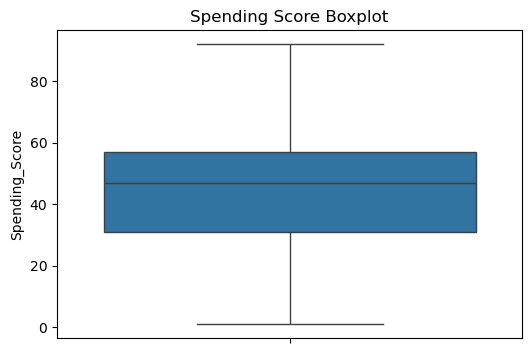

In [44]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Spending_Score"])
plt.title("Spending Score Boxplot")
plt.show()

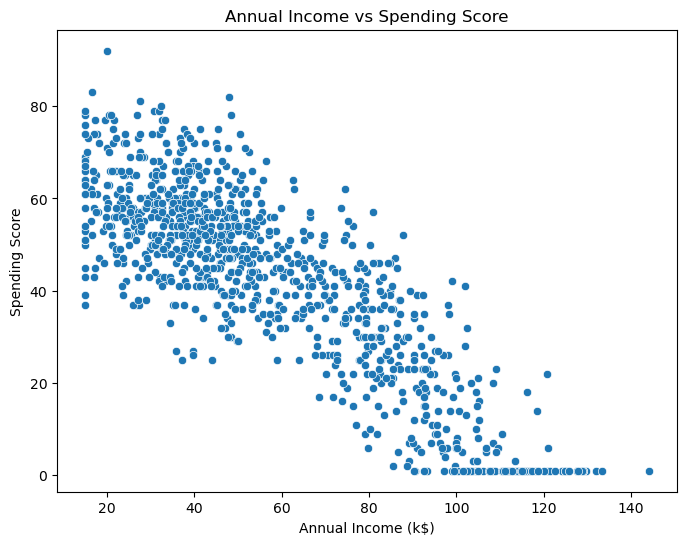

In [45]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Spending_Score")
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

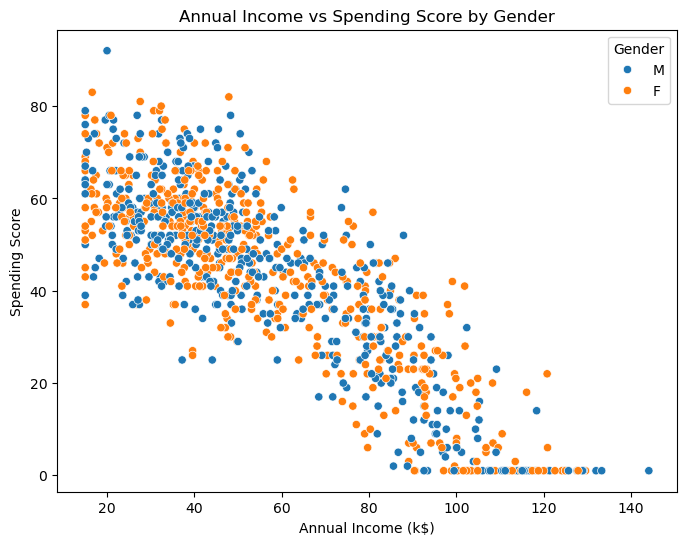

In [46]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Spending_Score",
    hue="Gender")
plt.title("Annual Income vs Spending Score by Gender")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

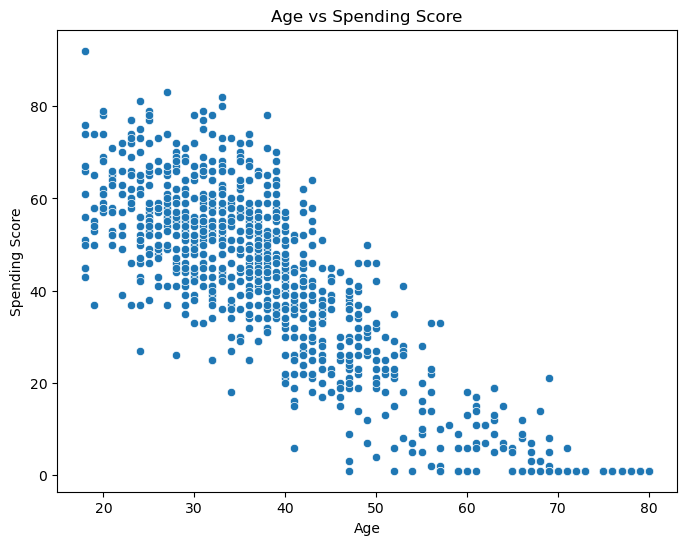

In [47]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Age",
    y="Spending_Score"
)

plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.show()

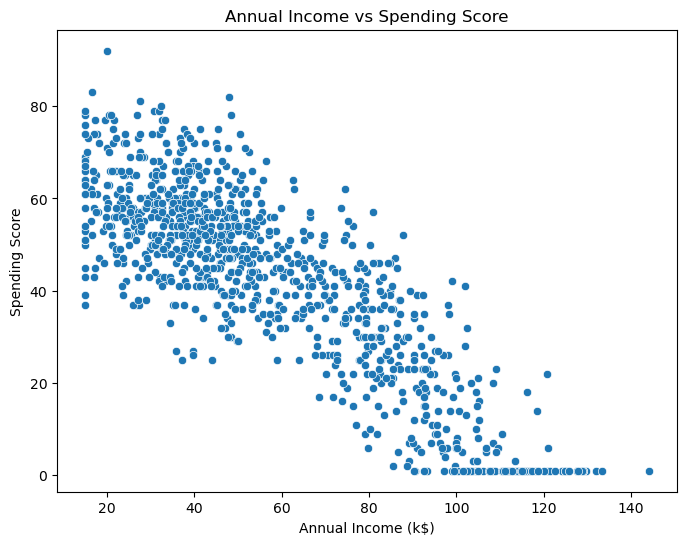

In [51]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Spending_Score"
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

In [53]:
df[["Age", "Spending_Score"]].corr()

,Age,Spending_Score
Age,1.000000,-0.835186
Spending_Score,-0.835186,1.000000


In [55]:
df[["Annual_Income", "Spending_Score"]].corr()

,Annual_Income,Spending_Score
Annual_Income,1.000000,-0.846073
Spending_Score,-0.846073,1.000000


In [56]:
numeric_df = df.select_dtypes(include=["number"])
numeric_df.corr()

,CustomerID,Age,Annual_Income,Spending_Score
CustomerID,1.000000,0.384249,0.328720,-0.364561
Age,0.384249,1.000000,0.923913,-0.835186
Annual_Income,0.328720,0.923913,1.000000,-0.846073
Spending_Score,-0.364561,-0.835186,-0.846073,1.000000


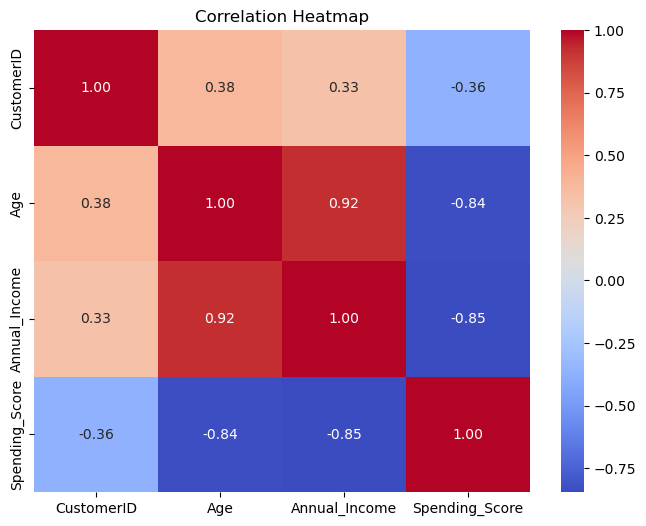

In [57]:
plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

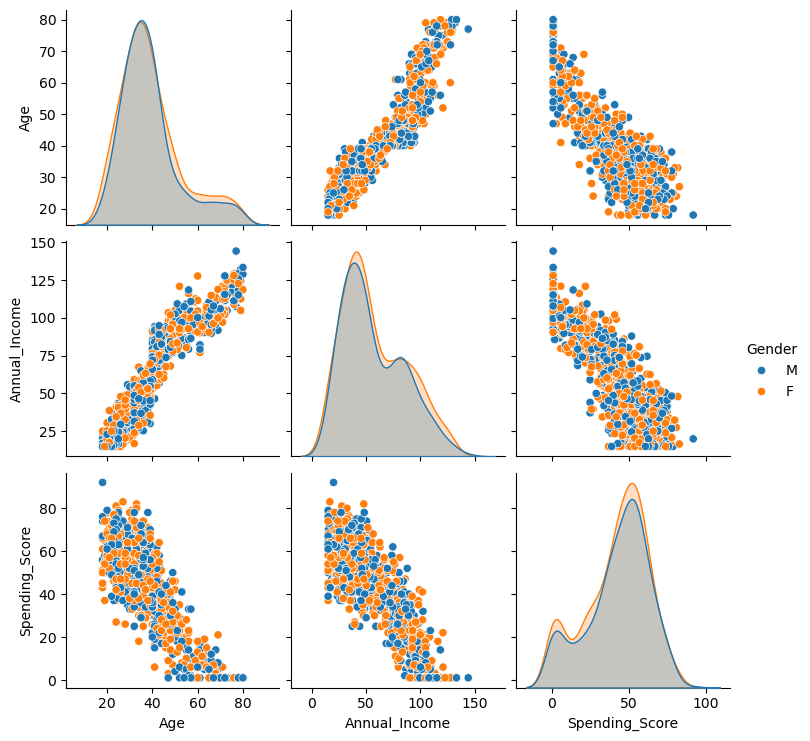

In [58]:
sns.pairplot(
    df,
    hue="Gender",
    vars=["Age", "Annual_Income", "Spending_Score"])
plt.show()

### Data for K-Means

In [60]:
X = df[["Annual_Income", "Spending_Score"]]
X.head()

,Annual_Income,Spending_Score
0,59.9,58.0
1,48.4,37.0
2,70.5,26.0
3,81.1,30.0
4,42.1,58.0


In [61]:
wcss = []

In [62]:
df[["Annual_Income", "Spending_Score"]].isnull().sum()
df[df[["Annual_Income", "Spending_Score"]].isnull().any(axis=1)]

,CustomerID,Gender,Age,Annual_Income,Spending_Score
105,1105,F,38.0,38.1,NaN
117,1117,M,26.0,22.7,NaN
187,1187,F,34.0,NaN,18.0
285,1285,F,19.0,NaN,65.0
391,1391,NaN,39.0,52.8,NaN
654,1654,F,56.0,86.2,NaN
682,1682,M,31.0,26.2,NaN
690,1690,F,32.0,25.2,NaN
891,1891,F,29.0,NaN,64.0
936,1936,F,62.0,NaN,11.0


In [63]:
X = df[["Annual_Income", "Spending_Score"]].dropna()

In [64]:
X.shape

(990, 2)

In [65]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [66]:
for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42,
        n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

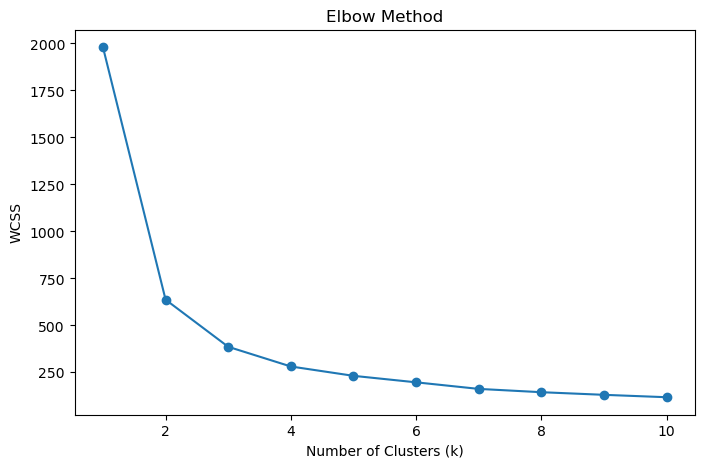

In [67]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.show()

In [68]:
kmeans = KMeans(
    n_clusters=4,
    init="k-means++",
    random_state=42,
    n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [69]:
df_cluster = df.dropna(subset=["Annual_Income", "Spending_Score"]).copy()
df_cluster["Cluster"] = clusters
df_cluster.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster
0,1000,M,39.0,59.9,58.0,1
1,1001,M,34.0,48.4,37.0,1
2,1002,F,40.0,70.5,26.0,0
3,1003,F,47.0,81.1,30.0,0
4,1004,F,33.0,42.1,58.0,3


In [70]:
df_cluster["Cluster"].value_counts()

Cluster
1    342
3    284
0    212
2    152
Name: count, dtype: int64

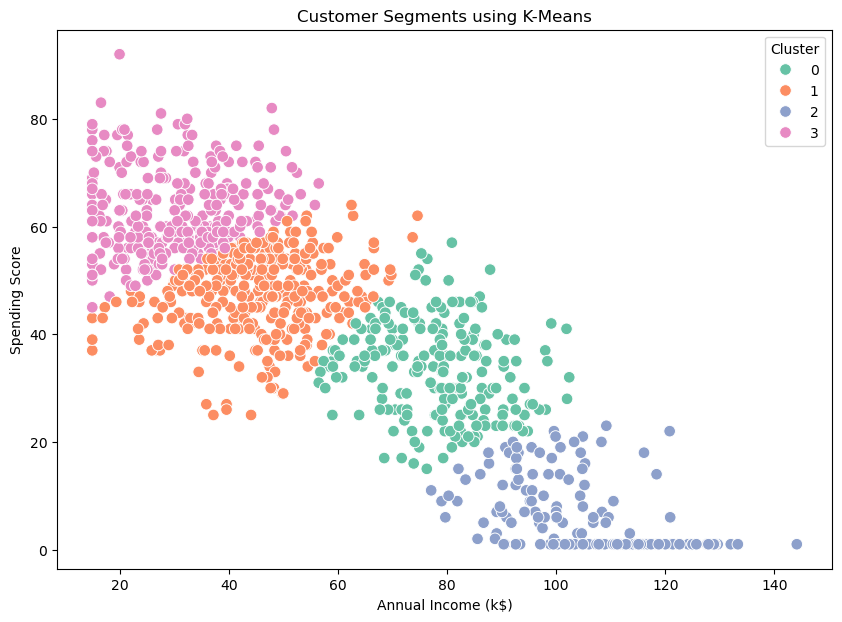

In [71]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_cluster,
    x="Annual_Income",
    y="Spending_Score",
    hue="Cluster",
    palette="Set2",
    s=70)
plt.title("Customer Segments using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

In [72]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

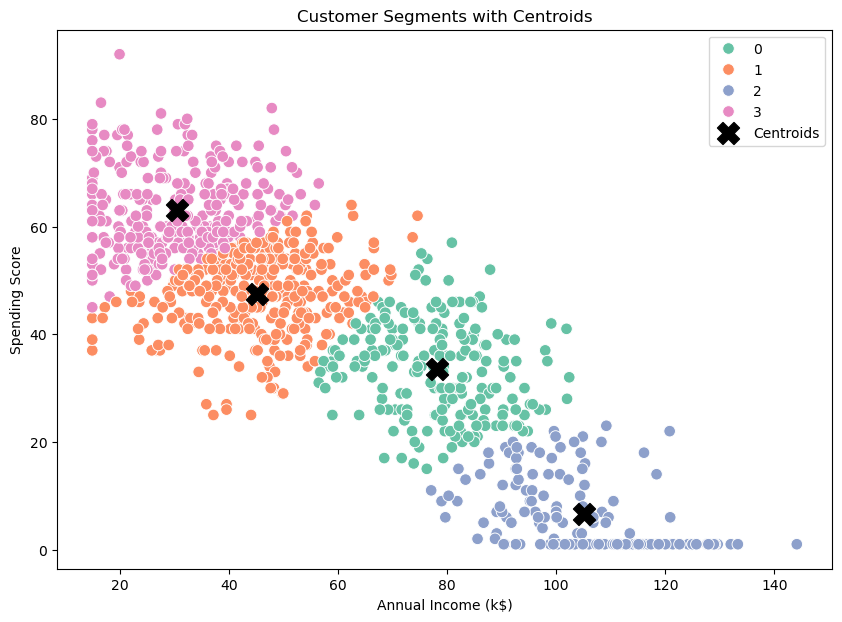

In [76]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_cluster,
    x="Annual_Income",
    y="Spending_Score",
    hue="Cluster",
    palette="Set2",
    s=70)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c="black",
    s=250,
    marker="X",
    label="Centroids")
plt.title("Customer Segments with Centroids")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

In [78]:
# Select features
X = df[["Annual_Income", "Spending_Score"]].dropna()

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train KMeans
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# Create clustered dataframe
df_cluster = df.dropna(
    subset=["Annual_Income", "Spending_Score"]
).copy()

df_cluster["Cluster"] = clusters

In [79]:
df_cluster.groupby("Cluster")[["Age", "Annual_Income", "Spending_Score"]].mean()

,Age,Annual_Income,Spending_Score
Cluster,,,
0,43.952607,78.197170,33.509434
1,33.626471,45.204971,47.426901
2,63.664474,105.154605,6.539474
3,28.298932,30.450352,63.077465


In [80]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", round(score, 4))

Silhouette Score: 0.3948
